In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
# ── Kaggle install block ─────────────────────────────────────────────────────
import subprocess, sys

pkgs = ['torch-geometric', 'torch-scatter', 'torch-sparse']
# torch-geometric needs matching torch version; install via pip
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'torch_geometric'], check=True)
# scipy, scikit-learn, matplotlib should already be present on Kaggle
print('All packages ready.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.9 MB/s eta 0:00:00
All packages ready.


In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os, glob, json, math, random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torch_geometric.data import Data as GData
from torch_geometric.nn import GATConv
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import cosine

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

Device: cuda


In [5]:
# ── Phase A architecture — must match exactly what was trained ────────────────
class MLPProjector(nn.Module):
    """Shared projector skeleton used by Pv, Pg, Pc."""
    def __init__(self, net: nn.Sequential):
        super().__init__()
        self.net = net

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)   # L2-normalise to unit sphere


def build_Pv(in_dim=1536):
    # 0:Linear → 1:GELU → 2:LayerNorm → 3:GELU → 4:Linear → 5:GELU → 6:LayerNorm → 7:GELU → 8:Linear
    return MLPProjector(nn.Sequential(
        nn.Linear(in_dim, 768),  # 0
        nn.GELU(),               # 1
        nn.LayerNorm(768),       # 2
        nn.GELU(),               # 3
        nn.Linear(768, 384),     # 4
        nn.GELU(),               # 5
        nn.LayerNorm(384),       # 6
        nn.GELU(),               # 7
        nn.Linear(384, 256),     # 8
    ))


def build_Pg(in_dim=50):
    return MLPProjector(nn.Sequential(
        nn.Linear(in_dim, 256),  # 0
        nn.GELU(),               # 1
        nn.LayerNorm(256),       # 2
        nn.GELU(),               # 3
        nn.Linear(256, 256),     # 4
    ))


def build_Pc(in_dim=15):
    return MLPProjector(nn.Sequential(
        nn.Linear(in_dim, 128),  # 0
        nn.GELU(),               # 1
        nn.LayerNorm(128),       # 2
        nn.GELU(),               # 3
        nn.Linear(128, 256),     # 4
    ))


class TriModalBridge(nn.Module):
    """Phase A model: three projectors + three learnable temperatures."""
    def __init__(self, vision_dim=1536):
        super().__init__()
        self.Pv = build_Pv(vision_dim)
        self.Pg = build_Pg()
        self.Pc = build_Pc()
        self.log_temp_vg = nn.Parameter(torch.tensor(0.0))
        self.log_temp_vc = nn.Parameter(torch.tensor(0.0))
        self.log_temp_gc = nn.Parameter(torch.tensor(0.0))

    def forward(self, vision, gene, cell):
        """Returns (zv, zg, zc): each (B, 256), L2-normalised."""
        return self.Pv(vision), self.Pg(gene), self.Pc(cell)


# ── Load weights ──────────────────────────────────────────────────────────────
PHASE_A_MODELS = {
    'UNI2-h':     '/kaggle/input/models/wanianaeem/phase-a-trimodal-models/pytorch/default/3/UNI2-h_scVI_RCTD_final_model.pt',
    'H-Optimus':  '/kaggle/input/models/wanianaeem/phase-a-trimodal-models/pytorch/default/3/H-Optimus-1_scVI_RCTD_final_model.pt',
    'CONCH':      '/kaggle/input/models/wanianaeem/phase-a-trimodal-models/pytorch/default/3/CONCHv1_scVI_RCTD_final_model.pt',
}

# Vision embedding dimensions per backbone
VISION_DIMS = {
    'UNI2-h':    1536,
    'H-Optimus': 1536,
    'CONCH':     512,
}


def load_phase_a(path: str, vision_dim: int = 1536, device=DEVICE) -> TriModalBridge:
    model = TriModalBridge(vision_dim=vision_dim)
    state = torch.load(path, map_location='cpu', weights_only=False)
    model.load_state_dict(state)
    model.to(device)
    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)
    print(f'Loaded & frozen: {Path(path).name}  (vision_dim={vision_dim})')
    return model


# ── SELECT BACKBONE HERE ──────────────────────────────────────────────────────
# Change ACTIVE_BACKBONE to 'UNI2-h', 'H-Optimus', or 'CONCH'
ACTIVE_BACKBONE = 'CONCH'   # <── CHANGE THIS LINE ONLY

phase_a    = load_phase_a(PHASE_A_MODELS[ACTIVE_BACKBONE],
                          vision_dim=VISION_DIMS[ACTIVE_BACKBONE])
VISION_DIM = VISION_DIMS[ACTIVE_BACKBONE]
print(f'Active backbone: {ACTIVE_BACKBONE}  |  vision_dim={VISION_DIM}')


Loaded & frozen: CONCHv1_scVI_RCTD_final_model.pt  (vision_dim=512)
Active backbone: CONCH  |  vision_dim=512


In [9]:
# ── Paths ─────────────────────────────────────────────────────────────────────
# All root directories — edit once, propagate everywhere
DATASET_ROOT = Path('/kaggle/input/datasets/wanianaeem/zenodo-pt-and-hm-dataset')
FEATURE_ROOT = DATASET_ROOT / 'Feature Extraction Embeddings'
GENE_ROOT    = DATASET_ROOT / 'Gene Embedding Extraction'
CELL_ROOT    = DATASET_ROOT / 'Cell Embedding Extraction'
META_CSV     = str(DATASET_ROOT / 'spot_spatial_coordinates.csv')

# ── Backbone → vision embedding directory & filename pattern ─────────────────
# Change ACTIVE_BACKBONE in Cell 3 and these paths will update automatically.
VISION_DIRS = {
    'UNI2-h':    FEATURE_ROOT / 'UNI2-h',       # files: {sample}_uni2h.pt
    'H-Optimus': FEATURE_ROOT / 'H-Optimus-1',  # files: {sample}_hoptimus.pt
    'CONCH':     FEATURE_ROOT / 'CONCH V1',         # files: {sample}_conch.pt
}

# Filename suffix per backbone (the part before .pt)
VISION_SUFFIX = {
    'UNI2-h':    '_uni2h',
    'H-Optimus': '_hoptimus',
    'CONCH':     '_conchv1',
}

VISION_DIR    = VISION_DIRS[ACTIVE_BACKBONE]
VIS_SUFFIX    = VISION_SUFFIX[ACTIVE_BACKBONE]

SCVI_DIR  = GENE_ROOT / 'scvi_latent_pt_embeddings/Features/scVI'
RCTD_DIR  = CELL_ROOT / 'RCTD/RCTD_embeddings/Features/RCTD'

# ── Gene name list (50 scVI latent → gene loadings) ───────────────────────────
# Provide a path to a CSV/TSV with columns ['scvi_dim', 'gene_name'] if you have
# scVI decoder gene loadings saved.  Set to None to skip gene-name mapping.
SCVI_GENE_LOADINGS_CSV = None   # e.g. DATASET_ROOT / 'scvi_gene_loadings.csv'

# ── Load and filter metadata ──────────────────────────────────────────────────
meta = pd.read_csv(META_CSV)

meta['cohort'] = meta['image'].apply(
    lambda x: 'HM' if '_HM' in x
    else ('PT' if '_T' in x and '_LNM' not in x
    else None)
)
meta = meta[meta['cohort'].isin(['PT', 'HM'])].reset_index(drop=True)

# Available samples = intersection of all three modality directories
vis_samples  = {p.stem.replace(VIS_SUFFIX, '') for p in VISION_DIR.glob(f'*{VIS_SUFFIX}.pt')}
scvi_samples = {p.name for p in SCVI_DIR.iterdir() if p.is_dir()}
rctd_samples = {p.name for p in RCTD_DIR.iterdir() if p.is_dir()}

available_samples = vis_samples & scvi_samples & rctd_samples
print(f'Backbone        : {ACTIVE_BACKBONE}')
print(f'Vision dir      : {VISION_DIR}')
print(f'Samples with all 3 modalities ({len(available_samples)}):')
print(sorted(available_samples))

meta = meta[meta['image'].isin(available_samples)].reset_index(drop=True)
meta['patient_id'] = meta['patient']

print(f'\nFinal metadata:')
print(f'  Total spots : {len(meta)}')
print(meta['cohort'].value_counts())
print(meta['image'].value_counts())


Backbone        : CONCH
Vision dir      : /kaggle/input/datasets/wanianaeem/zenodo-pt-and-hm-dataset/Feature Extraction Embeddings/CONCH V1
Samples with all 3 modalities (6):
['IU_PDA_HM11', 'IU_PDA_HM13', 'IU_PDA_T1', 'IU_PDA_T11', 'IU_PDA_T3', 'IU_PDA_T4']

Final metadata:
  Total spots : 20395
cohort
PT    14282
HM     6113
Name: count, dtype: int64
image
IU_PDA_T3      4354
IU_PDA_HM11    3931
IU_PDA_T4      3621
IU_PDA_T1      3530
IU_PDA_T11     2777
IU_PDA_HM13    2182
Name: count, dtype: int64


In [10]:
# ── Build (row,col) -> tensor lookup for scVI and RCTD (per-spot files) ──────
import re

def build_spot_map_from_dir(sample_dir: Path) -> dict:
    """
    Reads all per-spot .pt files in a sample subdirectory.
    Filename pattern: {sample_id}_patch-XXXXXX_{row}_{col}.pt
    Returns dict: (row, col) -> tensor
    """
    spot_map = {}
    for pt_file in sample_dir.glob('*.pt'):
        m = re.search(r'_(\d+)_(\d+)\.pt$', pt_file.name)
        if m:
            key = (int(m.group(1)), int(m.group(2)))
            spot_map[key] = torch.load(pt_file, map_location='cpu',
                                       weights_only=True).squeeze()
    return spot_map


def build_embedding_tensors(meta, vision_dir, vis_suffix, scvi_dir, rctd_dir):
    """
    Aligns all three modalities to metadata rows via (row, col).
    Backbone-agnostic: vision filename is resolved via vis_suffix.
    Returns vision (N, VISION_DIM), gene (N,50), cell (N,15), valid_idx.
    """
    vision_list, gene_list, cell_list, valid_idx = [], [], [], []

    for sample_id in sorted(meta['image'].unique()):
        print(f'Loading {sample_id}...', end=' ')
        sample_meta = meta[meta['image'] == sample_id]

        # Vision: one file per sample, dict with embeddings + patch_names
        vis_file = vision_dir / f'{sample_id}{vis_suffix}.pt'
        vis_data = torch.load(vis_file, map_location='cpu', weights_only=False)
        vis_map  = {}
        for name, emb in zip(vis_data['patch_names'], vis_data['embeddings']):
            m = re.search(r'_(\d+)_(\d+)$', name)
            if m:
                vis_map[(int(m.group(1)), int(m.group(2)))] = emb

        # scVI and RCTD: per-spot .pt files in subdirectory
        scvi_map = build_spot_map_from_dir(scvi_dir / sample_id)
        rctd_map = build_spot_map_from_dir(rctd_dir / sample_id)

        n_found = 0
        for idx, row in sample_meta.iterrows():
            key = (int(row['row']), int(row['col']))
            if key in vis_map and key in scvi_map and key in rctd_map:
                vision_list.append(vis_map[key])
                gene_list.append(scvi_map[key])
                cell_list.append(rctd_map[key])
                valid_idx.append(idx)
                n_found += 1

        print(f'{n_found}/{len(sample_meta)} spots matched')

    vision_t = torch.stack(vision_list)   # (N, VISION_DIM)
    gene_t   = torch.stack(gene_list)     # (N, 50)
    cell_t   = torch.stack(cell_list)     # (N, 15)

    return vision_t, gene_t, cell_t, valid_idx


vision_t, gene_t, cell_t, valid_idx = build_embedding_tensors(
    meta, VISION_DIR, VIS_SUFFIX, SCVI_DIR, RCTD_DIR
)

meta_aligned = meta.loc[valid_idx].reset_index(drop=True)
cohort_t     = torch.tensor(
    (meta_aligned['cohort'] == 'HM').astype(int).values,
    dtype=torch.long
)

is_hm = cohort_t == 1
is_pt = cohort_t == 0

print(f'\nFinal aligned dataset ({ACTIVE_BACKBONE}):')
print(f'  vision : {vision_t.shape}')
print(f'  gene   : {gene_t.shape}')
print(f'  cell   : {cell_t.shape}')
print(f'  PT spots: {is_pt.sum()}  HM spots: {is_hm.sum()}')


Loading IU_PDA_HM11... 3931/3931 spots matched
Loading IU_PDA_HM13... 2182/2182 spots matched
Loading IU_PDA_T1... 3530/3530 spots matched
Loading IU_PDA_T11... 2777/2777 spots matched
Loading IU_PDA_T3... 4354/4354 spots matched
Loading IU_PDA_T4... 3621/3621 spots matched

Final aligned dataset (CONCH):
  vision : torch.Size([20395, 512])
  gene   : torch.Size([20395, 50])
  cell   : torch.Size([20395, 15])
  PT spots: 14282  HM spots: 6113


In [11]:
# ── Alignment Head architecture ───────────────────────────────────────────────
class AlignmentHead(nn.Module):
    """256d fused embedding  →  128d aligned space."""
    def __init__(self, in_dim=256, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.LayerNorm(256), nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, out_dim)
        )

    def forward(self, z):
        return F.normalize(self.net(z), dim=-1)   # (B, 128) unit sphere


# ── Supervised Contrastive Loss ───────────────────────────────────────────────
class SupConLoss(nn.Module):
    """
    Supervised Contrastive Loss (Khosla et al. 2020).
    Positives are defined by a binary `pos_mask` passed in at call time —
    this lets us use gene-similarity as the positive criterion rather than
    just class label.
    """
    def __init__(self, temperature=0.07):
        super().__init__()
        self.tau = temperature

    def forward(self, features, pos_mask):
        """
        features : (B, 128) L2-normalised
        pos_mask : (B, B) bool — True if pair should be attracted
        """
        B = features.shape[0]
        sim = (features @ features.T) / self.tau          # (B, B)

        # Mask out diagonal (self-similarity)
        diag = torch.eye(B, dtype=torch.bool, device=features.device)
        sim  = sim.masked_fill(diag, -1e9)

        log_prob = sim - torch.logsumexp(sim, dim=1, keepdim=True)  # (B, B)

        # Average log-prob over positive pairs per anchor
        pos_mask = pos_mask & ~diag
        n_pos    = pos_mask.sum(dim=1).clamp(min=1).float()
        loss     = -(log_prob * pos_mask.float()).sum(dim=1) / n_pos
        return loss.mean()


def build_pos_mask_gene_sim(gene_batch: torch.Tensor,
                             cohort_batch: torch.Tensor,
                             sim_threshold: float = 0.7) -> torch.Tensor:
    """
    Positive pair = cross-cohort AND cosine similarity of gene vectors >= threshold.
    This is more biologically grounded than matching purely on PT/HM label.

    gene_batch  : (B, 50)  raw scVI latents
    cohort_batch: (B,)     int, 0=PT 1=HM
    """
    g_norm    = F.normalize(gene_batch.float(), dim=-1)
    gene_sim  = g_norm @ g_norm.T                          # (B, B)

    # Cross-cohort mask
    c = cohort_batch.unsqueeze(1)                          # (B, 1)
    cross_cohort = (c != c.T)                              # True if different cohort

    pos_mask = cross_cohort & (gene_sim >= sim_threshold)
    return pos_mask


print('AlignmentHead and SupConLoss defined.')

AlignmentHead and SupConLoss defined.


In [12]:
# ── Extract Phase A embeddings and build z_fused ─────────────────────────────
@torch.no_grad()
def extract_phase_a_embeddings(model, vision_t, gene_t, cell_t,
                                batch_size=512, device=DEVICE):
    """
    Runs all three modalities through frozen Phase A projectors.
    Fuses by averaging the three L2-normalised 256d embeddings.
    Returns z_fused (N, 256).
    """
    model.eval()
    zv_list, zg_list, zc_list = [], [], []
    N = len(vision_t)
    for i in range(0, N, batch_size):
        vb = vision_t[i:i+batch_size].to(device)
        gb = gene_t[i:i+batch_size].to(device)
        cb = cell_t[i:i+batch_size].to(device)
        zv, zg, zc = model(vb, gb, cb)
        zv_list.append(zv.cpu()); zg_list.append(zg.cpu()); zc_list.append(zc.cpu())
    zv_all = torch.cat(zv_list)   # (N, 256)
    zg_all = torch.cat(zg_list)   # (N, 256)
    zc_all = torch.cat(zc_list)   # (N, 256)
    z_fused = F.normalize((zv_all + zg_all + zc_all) / 3.0, dim=-1)  # (N, 256)
    return z_fused

z_fused = extract_phase_a_embeddings(phase_a, vision_t, gene_t, cell_t)
print(f'Phase A fused embeddings: {z_fused.shape}')

# ── Alignment Dataset ─────────────────────────────────────────────────────────
class AlignmentDataset(Dataset):
    def __init__(self, z_fused, gene_raw, cohort_labels):
        """
        z_fused       : (N, 256) tensor — Phase A fused embeddings
        gene_raw      : (N, 50)  tensor — raw scVI latents for pos_mask building
        cohort_labels : (N,)     int tensor — 0=PT, 1=HM
        """
        self.z       = z_fused
        self.g       = gene_raw
        self.cohort  = cohort_labels

    def __len__(self): return len(self.z)

    def __getitem__(self, idx):
        return self.z[idx], self.g[idx], self.cohort[idx]


# gene_t and cohort_t are already available from Cell 5
align_ds     = AlignmentDataset(z_fused, gene_t, cohort_t)
align_loader = DataLoader(align_ds, batch_size=512, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
print(f'AlignmentDataset ready: {len(align_ds)} spots')


Phase A fused embeddings: torch.Size([20395, 256])
AlignmentDataset ready: 20395 spots


In [13]:
# ── Train Module 1 ────────────────────────────────────────────────────────────
ALIGN_EPOCHS     = 30
ALIGN_LR         = 3e-4
GENE_SIM_THRESH  = 0.7    # cosine similarity threshold for positive pairs

align_head  = AlignmentHead(in_dim=256, out_dim=128).to(DEVICE)
supcon_loss = SupConLoss(temperature=0.07)
optim_align = torch.optim.AdamW(align_head.parameters(), lr=ALIGN_LR, weight_decay=1e-4)
sched_align = torch.optim.lr_scheduler.CosineAnnealingLR(optim_align, T_max=ALIGN_EPOCHS)

align_losses = []

for epoch in range(1, ALIGN_EPOCHS + 1):
    align_head.train()
    ep_loss = 0.0
    n_batches_with_pos = 0

    for z_batch, g_batch, c_batch in align_loader:
        z_batch = z_batch.to(DEVICE)
        g_batch = g_batch.to(DEVICE)
        c_batch = c_batch.to(DEVICE)

        pos_mask = build_pos_mask_gene_sim(g_batch, c_batch, GENE_SIM_THRESH).to(DEVICE)

        # Skip batch if no positive pairs exist (sparse cross-cohort similarity)
        if pos_mask.sum() == 0:
            continue
        n_batches_with_pos += 1

        z_aligned = align_head(z_batch)          # (B, 128)
        loss      = supcon_loss(z_aligned, pos_mask)

        optim_align.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(align_head.parameters(), 1.0)
        optim_align.step()
        ep_loss += loss.item()

    sched_align.step()
    avg = ep_loss / max(n_batches_with_pos, 1)
    align_losses.append(avg)

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{ALIGN_EPOCHS} | SupCon Loss: {avg:.4f} '
              f'| Batches w/ positives: {n_batches_with_pos}/{len(align_loader)}')

# Save
torch.save(align_head.state_dict(), '/kaggle/working/phase_b_align_head.pt')
print('\nModule 1 saved.')

Epoch   1/30 | SupCon Loss: 1.9742 | Batches w/ positives: 39/39
Epoch   5/30 | SupCon Loss: 1.5108 | Batches w/ positives: 39/39
Epoch  10/30 | SupCon Loss: 1.3872 | Batches w/ positives: 39/39
Epoch  15/30 | SupCon Loss: 1.3506 | Batches w/ positives: 39/39
Epoch  20/30 | SupCon Loss: 1.3215 | Batches w/ positives: 39/39
Epoch  25/30 | SupCon Loss: 1.2887 | Batches w/ positives: 39/39
Epoch  30/30 | SupCon Loss: 1.3106 | Batches w/ positives: 39/39

Module 1 saved.


In [14]:
# ── Extract aligned 128d embeddings ──────────────────────────────────────────
@torch.no_grad()
def get_aligned_embeddings(align_head, z_fused, batch_size=512, device=DEVICE):
    align_head.eval()
    z_all = []
    for i in range(0, len(z_fused), batch_size):
        chunk = z_fused[i:i+batch_size].to(device)
        z_all.append(align_head(chunk).cpu())
    return torch.cat(z_all)   # (N, 128)

z_aligned = get_aligned_embeddings(align_head, z_fused)
print(f'Aligned embeddings: {z_aligned.shape}')

# Split by cohort
is_hm  = cohort_t == 1
is_pt  = cohort_t == 0
z_hm   = z_aligned[is_hm]   # HM spots in 128d
z_pt   = z_aligned[is_pt]   # PT spots in 128d
print(f'PT: {z_pt.shape[0]}  HM: {z_hm.shape[0]}')

Aligned embeddings: torch.Size([20395, 128])
PT: 14282  HM: 6113


In [15]:
# ── Compute Δ_meta ────────────────────────────────────────────────────────────
mu_hm = z_hm.mean(dim=0)   # (128,) HM centroid
mu_pt = z_pt.mean(dim=0)   # (128,) PT centroid

delta_meta = mu_hm - mu_pt                          # metastatic direction vector
delta_meta_norm = F.normalize(delta_meta.unsqueeze(0), dim=-1).squeeze(0)  # unit vector

print(f'Δ_meta vector computed. L2 norm: {delta_meta.norm().item():.4f}')
print(f'Cosine similarity between PT and HM centroids: '
      f'{F.cosine_similarity(mu_pt.unsqueeze(0), mu_hm.unsqueeze(0)).item():.4f}')

Δ_meta vector computed. L2 norm: 0.1400
Cosine similarity between PT and HM centroids: 0.8783


In [16]:
# ── Per-spot metastatic direction score ───────────────────────────────────────
def compute_metastatic_direction_score(z_aligned: torch.Tensor,
                                        mu_pt: torch.Tensor,
                                        delta_norm: torch.Tensor) -> torch.Tensor:
    """
    score_i = cos_sim(z_i - μ_PT,  Δ_meta_norm)
    Output range: [-1, 1]; higher = more HM-like
    Min-max scaled to [0, 1] for interpretability.
    """
    diff   = z_aligned - mu_pt.unsqueeze(0)         # (N, 128)
    diff_n = F.normalize(diff, dim=-1)               # (N, 128)
    scores = (diff_n * delta_norm.unsqueeze(0)).sum(dim=-1)  # (N,)

    # Min-max normalise
    s_min, s_max = scores.min(), scores.max()
    scores_scaled = (scores - s_min) / (s_max - s_min + 1e-8)
    return scores_scaled


meta_direction_scores = compute_metastatic_direction_score(
    z_aligned, mu_pt, delta_meta_norm
)   # (N,) in [0, 1]

# Quick sanity: HM spots should score higher on average
print(f'Mean score — PT: {meta_direction_scores[is_pt].mean():.3f}  '
      f'HM: {meta_direction_scores[is_hm].mean():.3f}')

Mean score — PT: 0.482  HM: 0.572


Top 10 global gene drivers (positive = drives toward HM):
gene_label  coefficient
scVI_dim28     0.059425
scVI_dim43     0.040077
scVI_dim19     0.035095
 scVI_dim8     0.034089
 scVI_dim5     0.031265
scVI_dim30     0.024929
 scVI_dim3     0.023009
scVI_dim36     0.022139
scVI_dim33     0.018098
scVI_dim47     0.014388

Top 10 negative drivers (anchor toward PT):
gene_label  coefficient
scVI_dim46    -0.035449
scVI_dim37    -0.042652
scVI_dim40    -0.042707
scVI_dim44    -0.054263
 scVI_dim1    -0.062589
scVI_dim11    -0.065088
scVI_dim17    -0.071102
scVI_dim25    -0.093740
scVI_dim45    -0.095798
scVI_dim15    -0.131974

Top 15 gene drivers per sample saved.
Unique driver genes detected across all samples: 40


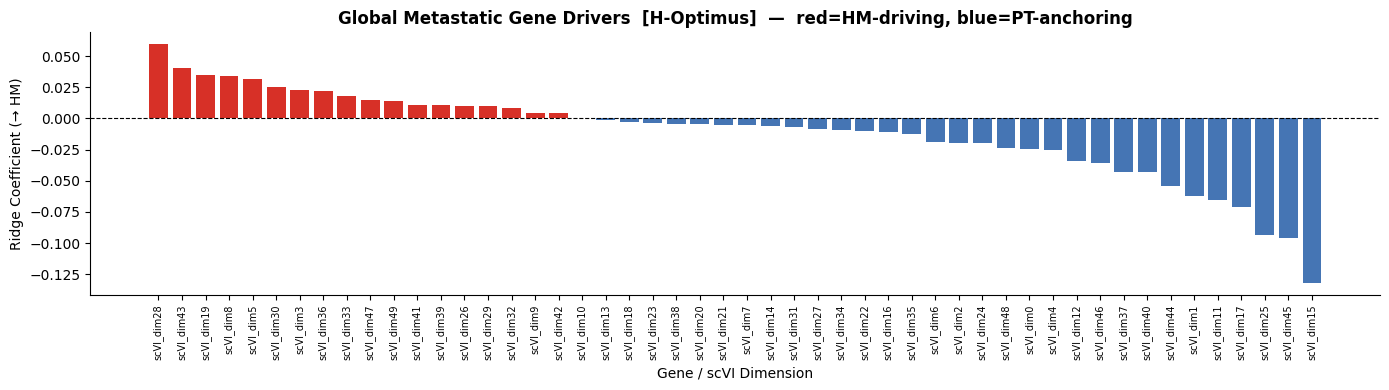

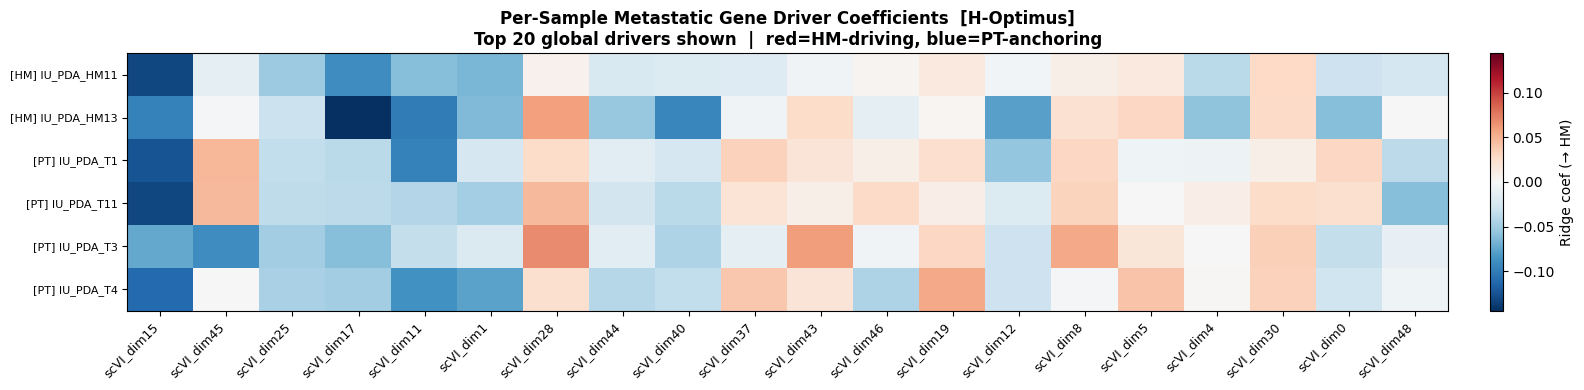

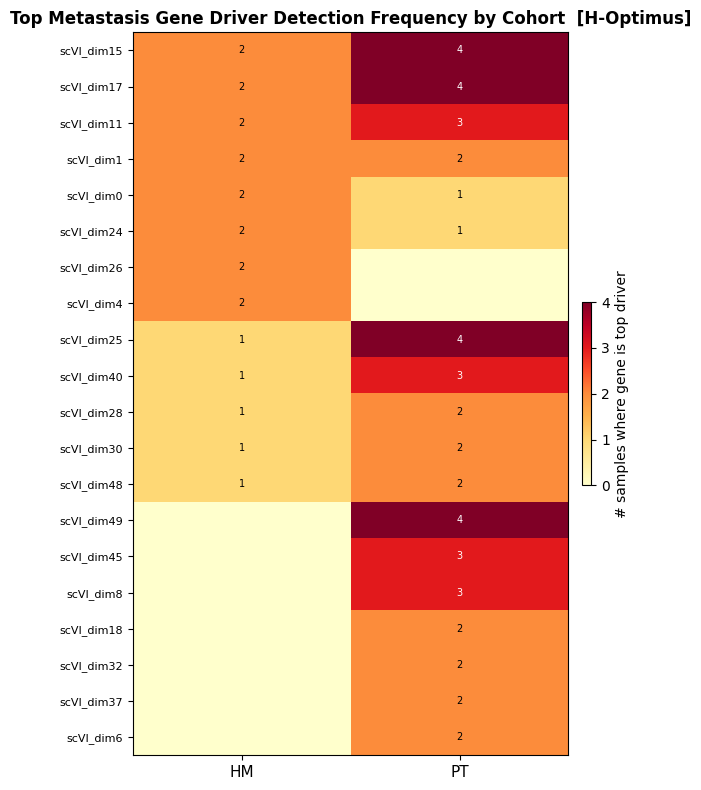

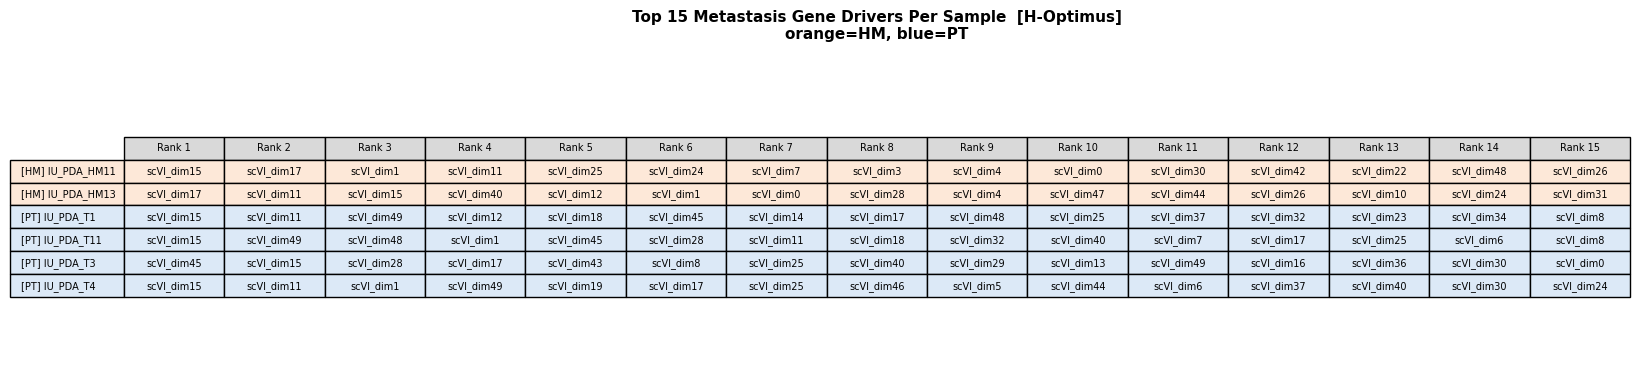


Gene driver heatmaps saved:
  global_gene_driver_bar.png
  per_sample_gene_driver_heatmap.png
  gene_driver_frequency_heatmap.png
  top_driver_gene_table_heatmap.png


In [13]:
# ── Top metastasis gene drivers per sample ───────────────────────────────────
# For each spot we fit a Ridge model: scVI latent dims → meta_direction_score.
# The top-weighted dims are the "gene drivers" for that spot.
# We then aggregate to per-sample top driver profiles and plot heatmaps.

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ── Optional: load scVI gene loadings to get real gene names ─────────────────
if SCVI_GENE_LOADINGS_CSV is not None:
    gene_loading_df = pd.read_csv(SCVI_GENE_LOADINGS_CSV)
    DIM_LABELS = [
        gene_loading_df.loc[gene_loading_df['scvi_dim'] == d, 'gene_name'].values[0]
        if d in gene_loading_df['scvi_dim'].values else f'scVI_dim{d}'
        for d in range(gene_t.shape[1])
    ]
else:
    DIM_LABELS = [f'scVI_dim{d}' for d in range(gene_t.shape[1])]

# ── Global Ridge: all spots together ─────────────────────────────────────────
X_all = gene_t.numpy()
y_all = meta_direction_scores.numpy()

scaler_global = StandardScaler()
X_all_scaled  = scaler_global.fit_transform(X_all)

ridge_global  = Ridge(alpha=1.0)
ridge_global.fit(X_all_scaled, y_all)

global_attribution = pd.DataFrame({
    'gene_label':  DIM_LABELS,
    'coefficient': ridge_global.coef_
}).sort_values('coefficient', ascending=False)

print('Top 10 global gene drivers (positive = drives toward HM):')
print(global_attribution.head(10).to_string(index=False))
print('\nTop 10 negative drivers (anchor toward PT):')
print(global_attribution.tail(10).to_string(index=False))

# ── Per-sample Ridge: top N drivers per sample ───────────────────────────────
TOP_N_DRIVERS = 15   # how many top drivers to report per sample

sample_ids    = meta_aligned['image'].values
unique_samples = sorted(set(sample_ids))
cohort_map    = meta_aligned.set_index('image')['cohort'].to_dict()

per_sample_coef = {}   # sample_id -> coef array (n_dims,)

for sid in unique_samples:
    mask   = sample_ids == sid
    X_s    = X_all_scaled[mask]
    y_s    = y_all[mask]
    if len(y_s) < 10:
        continue
    r = Ridge(alpha=1.0)
    r.fit(X_s, y_s)
    per_sample_coef[sid] = r.coef_

# Build coefficient matrix: samples × scVI dims
coef_df = pd.DataFrame(per_sample_coef, index=DIM_LABELS).T   # (n_samples, n_dims)
coef_df.index.name = 'sample_id'

# For each sample: record detected top driver genes (by abs coefficient)
top_driver_records = []
for sid, coefs in per_sample_coef.items():
    abs_coefs = np.abs(coefs)
    top_idx   = np.argsort(abs_coefs)[::-1][:TOP_N_DRIVERS]
    for rank, idx in enumerate(top_idx, 1):
        top_driver_records.append({
            'sample_id':  sid,
            'cohort':     cohort_map.get(sid, 'Unknown'),
            'rank':       rank,
            'gene_label': DIM_LABELS[idx],
            'scvi_dim':   idx,
            'coefficient': coefs[idx],
            'abs_coef':   abs_coefs[idx],
        })

top_driver_df = pd.DataFrame(top_driver_records)
top_driver_df.to_csv('/kaggle/working/top_meta_gene_drivers_per_sample.csv', index=False)
print(f'\nTop {TOP_N_DRIVERS} gene drivers per sample saved.')
print(f'Unique driver genes detected across all samples: '
      f'{top_driver_df["gene_label"].nunique()}')

# ── Heatmap 1: Global Ridge coefficients (all dims) ──────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
colors  = ['#d73027' if c > 0 else '#4575b4' for c in global_attribution['coefficient']]
ax.bar(range(len(global_attribution)), global_attribution['coefficient'], color=colors, width=0.8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(range(len(global_attribution)))
ax.set_xticklabels(global_attribution['gene_label'], rotation=90, fontsize=7)
ax.set_xlabel('Gene / scVI Dimension')
ax.set_ylabel('Ridge Coefficient (→ HM)')
ax.set_title(f'Global Metastatic Gene Drivers  [{ACTIVE_BACKBONE}]  —  red=HM-driving, blue=PT-anchoring',
             fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('/kaggle/working/global_gene_driver_bar.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# ── Heatmap 2: Per-sample coefficient heatmap (top global drivers only) ──────
# Select top-20 drivers by global absolute coefficient for readability
top20_global = global_attribution.reindex(
    global_attribution['coefficient'].abs().nlargest(20).index
)['gene_label'].tolist()

hm_data = coef_df[top20_global].copy()
# Sort rows: HM samples first, then PT
cohort_order = pd.Series({sid: cohort_map.get(sid, 'Z') for sid in hm_data.index})
hm_data = hm_data.loc[cohort_order.sort_values().index]

fig, ax = plt.subplots(figsize=(16, max(4, len(hm_data) * 0.5)))
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

vmax = hm_data.abs().values.max()
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
im   = ax.imshow(hm_data.values, aspect='auto', cmap='RdBu_r', norm=norm)

ax.set_xticks(range(len(top20_global)))
ax.set_xticklabels(top20_global, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(hm_data)))

# Annotate row labels with cohort colour
yticklabels = []
for sid in hm_data.index:
    c = cohort_map.get(sid, '?')
    yticklabels.append(f'[{c}] {sid}')
ax.set_yticklabels(yticklabels, fontsize=8)

plt.colorbar(im, ax=ax, fraction=0.02, pad=0.03, label='Ridge coef (→ HM)')
ax.set_title(f'Per-Sample Metastatic Gene Driver Coefficients  [{ACTIVE_BACKBONE}]\n'
             f'Top 20 global drivers shown  |  red=HM-driving, blue=PT-anchoring',
             fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/per_sample_gene_driver_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# ── Heatmap 3: Top-N driver detection frequency per cohort ───────────────────
# Which genes appear most often in the top-N drivers, split by cohort?
freq_df = (
    top_driver_df
    .groupby(['cohort', 'gene_label'])
    .size()
    .reset_index(name='n_samples_detected')
)

pivot_freq = freq_df.pivot(index='gene_label', columns='cohort', values='n_samples_detected').fillna(0)
# Keep genes detected in at least 2 samples
pivot_freq = pivot_freq[(pivot_freq > 1).any(axis=1)]
pivot_freq = pivot_freq.sort_values(pivot_freq.columns.tolist(), ascending=False)

fig, ax = plt.subplots(figsize=(max(6, len(pivot_freq.columns) * 3),
                                 max(6, len(pivot_freq) * 0.4)))
im2 = ax.imshow(pivot_freq.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(pivot_freq.columns)))
ax.set_xticklabels(pivot_freq.columns.tolist(), fontsize=11)
ax.set_yticks(range(len(pivot_freq)))
ax.set_yticklabels(pivot_freq.index.tolist(), fontsize=8)
plt.colorbar(im2, ax=ax, fraction=0.02, pad=0.03, label='# samples where gene is top driver')
ax.set_title(f'Top Metastasis Gene Driver Detection Frequency by Cohort  [{ACTIVE_BACKBONE}]',
             fontweight='bold')
# Annotate cells with counts
for i in range(pivot_freq.shape[0]):
    for j in range(pivot_freq.shape[1]):
        val = int(pivot_freq.values[i, j])
        if val > 0:
            ax.text(j, i, str(val), ha='center', va='center', fontsize=7,
                    color='black' if val < pivot_freq.values.max() * 0.7 else 'white')
plt.tight_layout()
plt.savefig('/kaggle/working/gene_driver_frequency_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# ── Heatmap 4: Per-sample top-N driver gene labels (ranked) ──────────────────
# Grid: samples (rows) × rank (cols), cells show gene name
pivot_rank = top_driver_df.pivot(index='sample_id', columns='rank', values='gene_label')
pivot_rank = pivot_rank.reindex(
    sorted(pivot_rank.index, key=lambda s: (cohort_map.get(s, 'Z'), s))
)

fig, ax = plt.subplots(figsize=(TOP_N_DRIVERS * 1.1, max(4, len(pivot_rank) * 0.55)))
ax.axis('off')
tbl = ax.table(
    cellText=pivot_rank.values,
    rowLabels=[f'[{cohort_map.get(s,"?")}] {s}' for s in pivot_rank.index],
    colLabels=[f'Rank {c}' for c in pivot_rank.columns],
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(7)
tbl.scale(1, 1.3)

# Colour rows by cohort
for (row_i, col_j), cell in tbl.get_celld().items():
    if row_i == 0:
        cell.set_facecolor('#d9d9d9')
    elif row_i > 0:
        sid = pivot_rank.index[row_i - 1]
        cohort = cohort_map.get(sid, '?')
        cell.set_facecolor('#fde8d8' if cohort == 'HM' else '#dce9f7')

ax.set_title(f'Top {TOP_N_DRIVERS} Metastasis Gene Drivers Per Sample  [{ACTIVE_BACKBONE}]\n'
             f'orange=HM, blue=PT',
             fontweight='bold', y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig('/kaggle/working/top_driver_gene_table_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

print('\nGene driver heatmaps saved:')
print('  global_gene_driver_bar.png')
print('  per_sample_gene_driver_heatmap.png')
print('  gene_driver_frequency_heatmap.png')
print('  top_driver_gene_table_heatmap.png')


## 6  Module 3 — Scoring MLP

A small MLP trained to output a **propensity score ∈ [0,1]** using the Module 2 direction scores as soft labels.

In [17]:
class ScoringMLP(nn.Module):
    """128d aligned embedding  →  scalar metastatic propensity score."""
    def __init__(self, in_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64), nn.LayerNorm(64), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(64, 32),     nn.GELU(),
            nn.Linear(32, 1),      nn.Sigmoid()
        )

    def forward(self, z):
        return self.net(z).squeeze(-1)   # (B,) in [0, 1]


class ScoreDataset(Dataset):
    def __init__(self, z_aligned, soft_labels):
        self.z = z_aligned
        self.y = soft_labels.float()

    def __len__(self): return len(self.z)
    def __getitem__(self, idx): return self.z[idx], self.y[idx]


score_ds     = ScoreDataset(z_aligned, meta_direction_scores)
score_loader = DataLoader(score_ds, batch_size=512, shuffle=True, num_workers=2)

scoring_mlp  = ScoringMLP().to(DEVICE)
optim_score  = torch.optim.AdamW(scoring_mlp.parameters(), lr=1e-3, weight_decay=1e-4)
sched_score  = torch.optim.lr_scheduler.CosineAnnealingLR(optim_score, T_max=20)

SCORE_EPOCHS = 20
score_losses = []

for epoch in range(1, SCORE_EPOCHS + 1):
    scoring_mlp.train()
    ep_loss = 0.0
    for z_b, y_b in score_loader:
        z_b, y_b = z_b.to(DEVICE), y_b.to(DEVICE)
        pred  = scoring_mlp(z_b)
        loss  = F.mse_loss(pred, y_b)        # regression against soft label
        # optionally add a cohort-separation term:
        # loss += F.binary_cross_entropy(pred, cohort_hard_label_batch)
        optim_score.zero_grad()
        loss.backward()
        optim_score.step()
        ep_loss += loss.item()

    sched_score.step()
    avg = ep_loss / len(score_loader)
    score_losses.append(avg)
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:2d}/{SCORE_EPOCHS} | Score MSE: {avg:.5f}')

torch.save(scoring_mlp.state_dict(), '/kaggle/working/phase_b_scoring_mlp.pt')
print('\nModule 3 saved.')

Epoch  1/20 | Score MSE: 0.00908
Epoch  5/20 | Score MSE: 0.00069
Epoch 10/20 | Score MSE: 0.00040
Epoch 15/20 | Score MSE: 0.00033
Epoch 20/20 | Score MSE: 0.00031

Module 3 saved.


In [18]:
# ── Collect MLP scores ────────────────────────────────────────────────────────
@torch.no_grad()
def get_mlp_scores(model, z_aligned, batch_size=512, device=DEVICE):
    model.eval()
    out = []
    for i in range(0, len(z_aligned), batch_size):
        chunk = z_aligned[i:i+batch_size].to(device)
        out.append(model(chunk).cpu())
    return torch.cat(out)

mlp_scores = get_mlp_scores(scoring_mlp, z_aligned)
print(f'MLP score stats — PT: {mlp_scores[is_pt].mean():.3f}  '
      f'HM: {mlp_scores[is_hm].mean():.3f}')

MLP score stats — PT: 0.481  HM: 0.570


## 7  Module 4 — Spatial GAT (Neighbourhood-Smoothed Score)

Builds a **k-NN spatial graph** per sample using Visium grid coordinates.  
A 2-layer GAT aggregates neighbour context → smoothed final score.

In [19]:
class SpatialGAT(nn.Module):
    """
    2-layer GAT operating on the 128d aligned embedding.
    Node feature = concat(z_aligned, mlp_score) = 129d
    Output: smoothed metastatic score per node.
    """
    def __init__(self, in_channels=129, hidden=64, heads=4):
        super().__init__()
        self.gat1 = GATConv(in_channels, hidden, heads=heads, dropout=0.1)
        self.gat2 = GATConv(hidden * heads, 1, heads=1, concat=False, dropout=0.1)

    def forward(self, x, edge_index):
        x = F.elu(self.gat1(x, edge_index))
        x = torch.sigmoid(self.gat2(x, edge_index))
        return x.squeeze(-1)   # (N,) in [0, 1]


def build_spatial_graph(rows, cols, k=6):
    """
    Build a k-NN graph from Visium (row, col) coordinates.
    Returns edge_index in COO format: (2, E).
    k=6 matches Visium hexagonal neighbourhood.
    """
    coords = np.column_stack([rows, cols])
    nbrs   = NearestNeighbors(n_neighbors=k+1, algorithm='ball_tree').fit(coords)
    _, idx = nbrs.kneighbors(coords)

    src, dst = [], []
    for i, neighbors in enumerate(idx):
        for j in neighbors[1:]:   # exclude self
            src.append(i); dst.append(j)
            src.append(j); dst.append(i)  # undirected

    edge_index = torch.tensor([src, dst], dtype=torch.long)
    return edge_index


print('SpatialGAT defined.')

SpatialGAT defined.


In [20]:
# ── Train GAT per-sample (or all-samples concatenated) ───────────────────────
# We train one shared GAT across all spots; spatial graphs are built per sample.

spatial_gat  = SpatialGAT(in_channels=129, hidden=64, heads=4).to(DEVICE)
optim_gat    = torch.optim.AdamW(spatial_gat.parameters(), lr=5e-4, weight_decay=1e-4)
GAT_EPOCHS   = 15

# Node features: concat aligned embedding + MLP score
node_feats_all = torch.cat([z_aligned, mlp_scores.unsqueeze(1)], dim=1)  # (N, 129)

# Build per-sample graphs and concatenate
def build_all_sample_graph(spot_meta, node_feats, mlp_scores):
    """
    Returns a single large PyG Data object (disjoint union of per-sample graphs).
    """
    sample_ids = np.array(spot_meta['image'])
    rows_arr   = np.array(spot_meta['row'])
    cols_arr   = np.array(spot_meta['col'])

    all_edges  = []
    offset     = 0

    for sid in np.unique(sample_ids):
        mask  = sample_ids == sid
        idx   = np.where(mask)[0]
        r, c  = rows_arr[idx], cols_arr[idx]
        ei    = build_spatial_graph(r, c, k=6)   # local edges
        all_edges.append(ei + offset)             # shift to global idx
        offset += len(idx)

    edge_index = torch.cat(all_edges, dim=1)
    return GData(x=node_feats, edge_index=edge_index, y=mlp_scores)


graph_data = build_all_sample_graph(meta_aligned, node_feats_all, mlp_scores)
print(f'Graph: {graph_data.num_nodes} nodes, {graph_data.num_edges} edges')

# Move to device
gx  = graph_data.x.to(DEVICE)
gei = graph_data.edge_index.to(DEVICE)
gy  = graph_data.y.to(DEVICE)

gat_losses = []
for epoch in range(1, GAT_EPOCHS + 1):
    spatial_gat.train()
    pred  = spatial_gat(gx, gei)

    # Spatial consistency: smoothed score should be close to MLP score
    mse   = F.mse_loss(pred, gy)

    # Optional: push PT and HM apart in score space
    ct    = cohort_t.to(DEVICE).float()
    sep   = F.binary_cross_entropy(pred, ct)
    loss  = mse

    optim_gat.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(spatial_gat.parameters(), 1.0)
    optim_gat.step()
    gat_losses.append(loss.item())

    if epoch % 3 == 0 or epoch == 1:
        print(f'Epoch {epoch:2d}/{GAT_EPOCHS} | GAT Loss: {loss.item():.5f} '
              f'(MSE={mse.item():.5f}, Sep={sep.item():.5f})')

torch.save(spatial_gat.state_dict(), '/kaggle/working/phase_b_spatial_gat.pt')
print('\nModule 4 saved.')

Graph: 20395 nodes, 244740 edges
Epoch  1/15 | GAT Loss: 0.03136 (MSE=0.03136, Sep=0.69685)
Epoch  3/15 | GAT Loss: 0.02737 (MSE=0.02737, Sep=0.69425)
Epoch  6/15 | GAT Loss: 0.02228 (MSE=0.02228, Sep=0.68883)
Epoch  9/15 | GAT Loss: 0.01828 (MSE=0.01828, Sep=0.68451)
Epoch 12/15 | GAT Loss: 0.01518 (MSE=0.01518, Sep=0.68121)
Epoch 15/15 | GAT Loss: 0.01294 (MSE=0.01294, Sep=0.67962)

Module 4 saved.


In [21]:
# ── Final smoothed scores ─────────────────────────────────────────────────────
@torch.no_grad()
def get_gat_scores(model, gx, gei, device=DEVICE):
    model.eval()
    return model(gx.to(device), gei.to(device)).cpu()

final_scores = get_gat_scores(spatial_gat, gx, gei)

print(f'Final GAT-smoothed score stats:')
print(f'  PT: mean={final_scores[is_pt].mean():.3f}  std={final_scores[is_pt].std():.3f}')
print(f'  HM: mean={final_scores[is_hm].mean():.3f}  std={final_scores[is_hm].std():.3f}')

Final GAT-smoothed score stats:
  PT: mean=0.493  std=0.099
  HM: mean=0.542  std=0.106


In [22]:
# ── Build results DataFrame ───────────────────────────────────────────────────
results = pd.DataFrame({
    'spot_barcode':       meta_aligned.index,
    'sample_id':          meta_aligned['image'],
    'cohort':             meta_aligned['cohort'],
    'row':                meta_aligned['row'],
    'col':                meta_aligned['col'],
    'direction_score':    meta_direction_scores.numpy(),   # Module 2
    'mlp_score':          mlp_scores.numpy(),              # Module 3
    'final_score':        final_scores.numpy(),            # Module 4 (GAT)
})

results.to_csv('/kaggle/working/phase_b_spot_scores.csv', index=False)
print(results.groupby('cohort')[['direction_score','mlp_score','final_score']].describe())

       direction_score                                                    \
                 count      mean       std       min       25%       50%   
cohort                                                                     
HM              6113.0  0.572056  0.179924  0.031545  0.436117  0.576035   
PT             14282.0  0.481921  0.179392  0.000000  0.352200  0.479384   

                           mlp_score            ...                      \
             75%       max     count      mean  ...       75%       max   
cohort                                          ...                       
HM      0.720330  1.000000    6113.0  0.570434  ...  0.719539  0.905302   
PT      0.610176  0.972874   14282.0  0.480944  ...  0.606089  0.902769   

       final_score                                                    \
             count      mean       std       min       25%       50%   
cohort                                                                 
HM          6113.0  0.54157

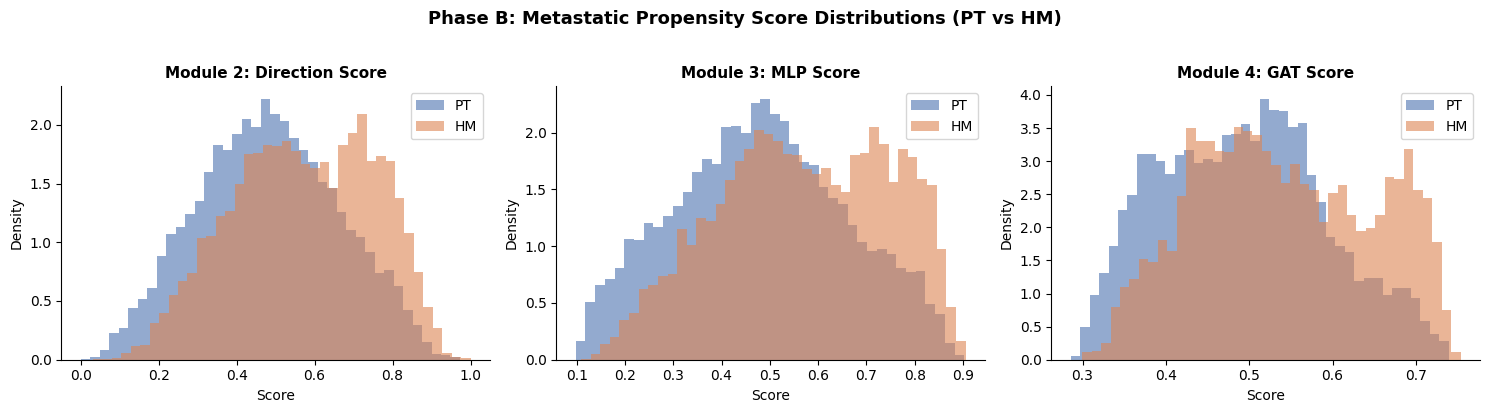

In [23]:
# ── Plot 1: Score distributions by cohort ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
score_cols = ['direction_score', 'mlp_score', 'final_score']
titles     = ['Module 2: Direction Score', 'Module 3: MLP Score', 'Module 4: GAT Score']

for ax, col, title in zip(axes, score_cols, titles):
    for cohort, color in [('PT', '#4C72B0'), ('HM', '#DD8452')]:
        vals = results.loc[results['cohort'] == cohort, col]
        ax.hist(vals, bins=40, alpha=0.6, color=color, label=cohort, density=True)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Score')
    ax.set_ylabel('Density')
    ax.legend()
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Phase B: Metastatic Propensity Score Distributions (PT vs HM)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Plotting 6 samples...


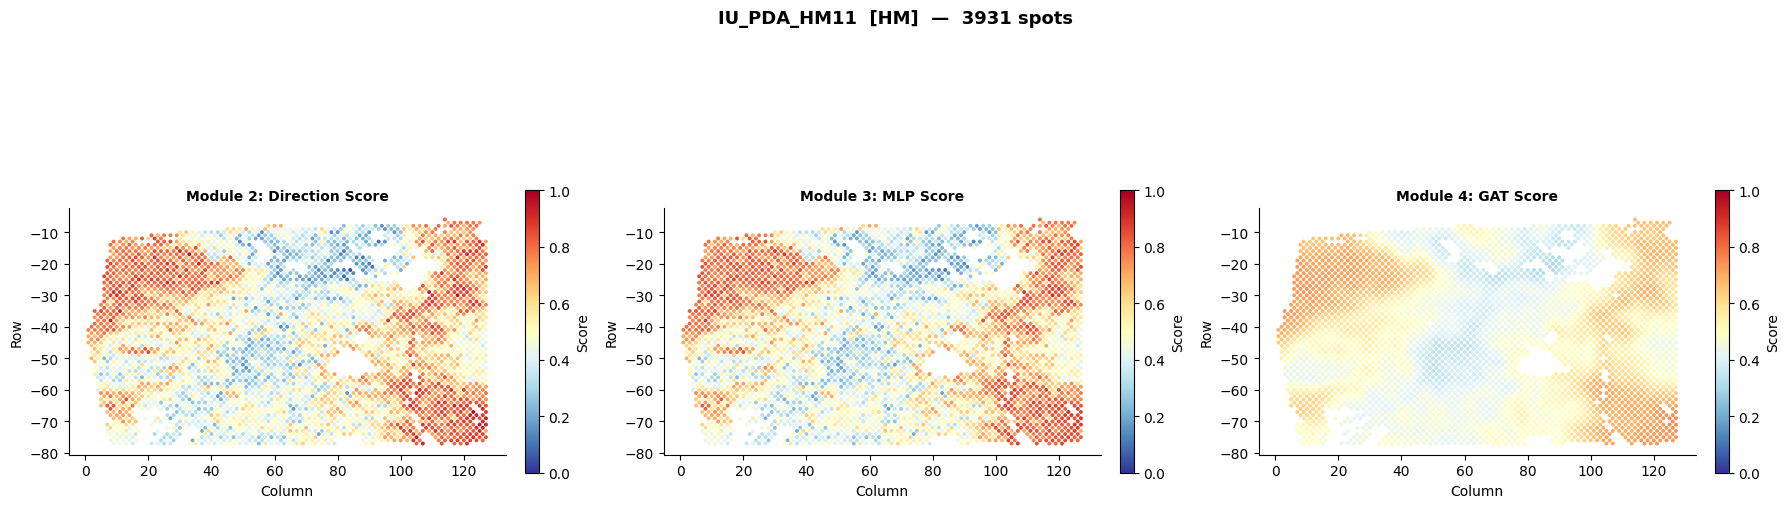

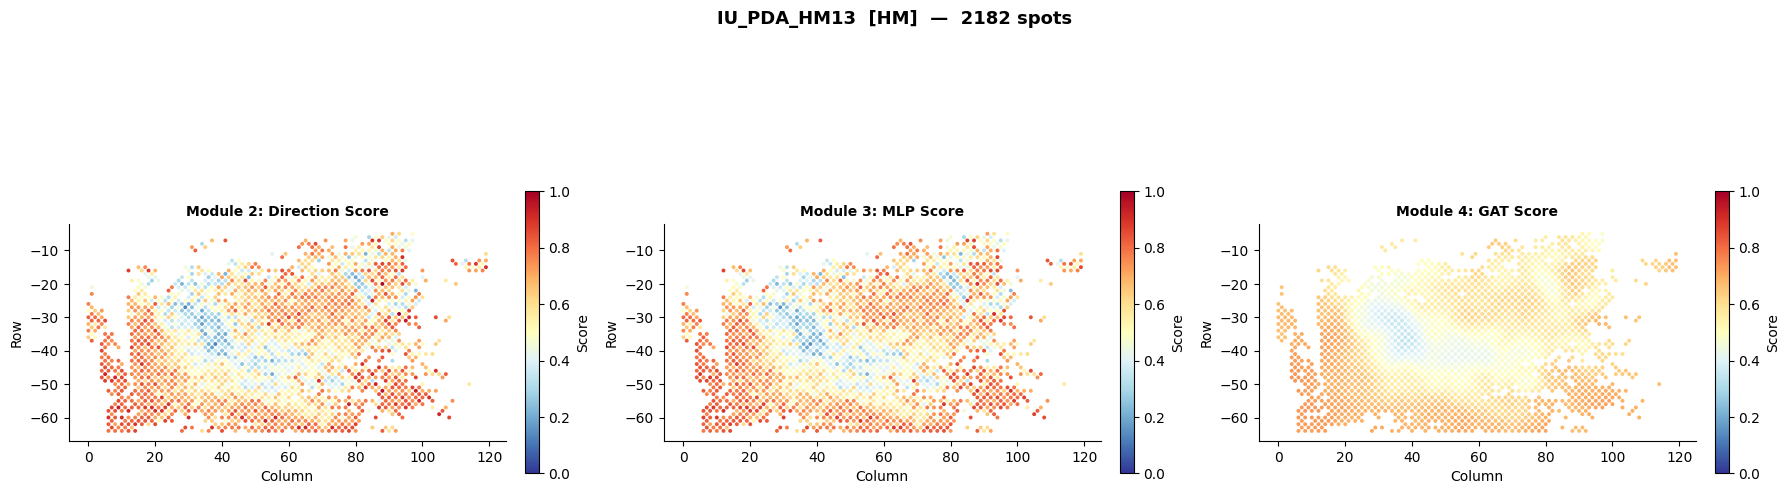

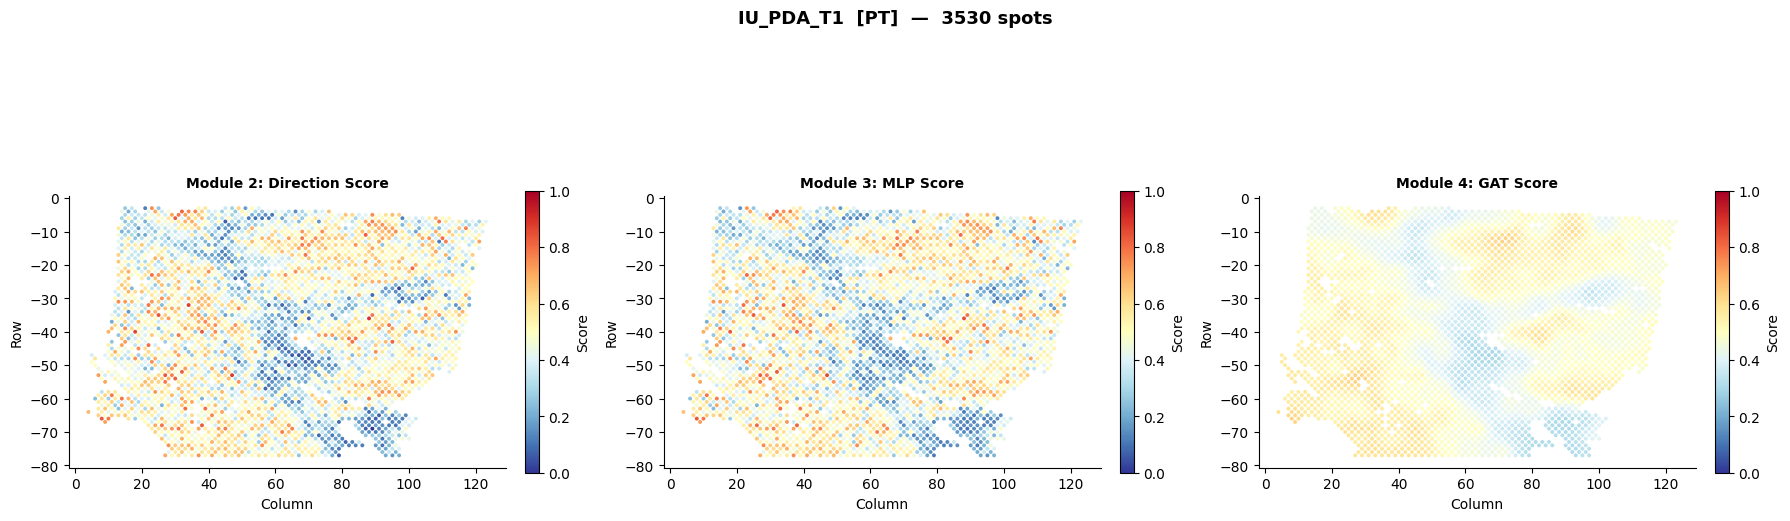

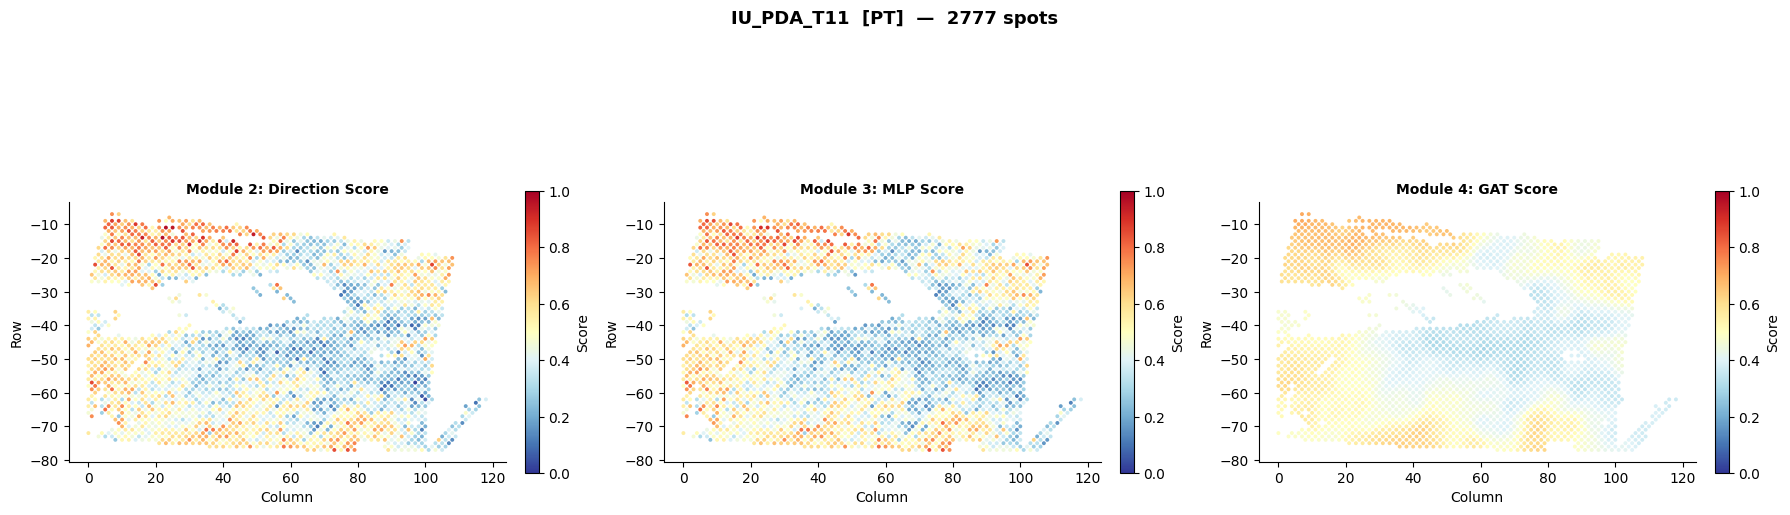

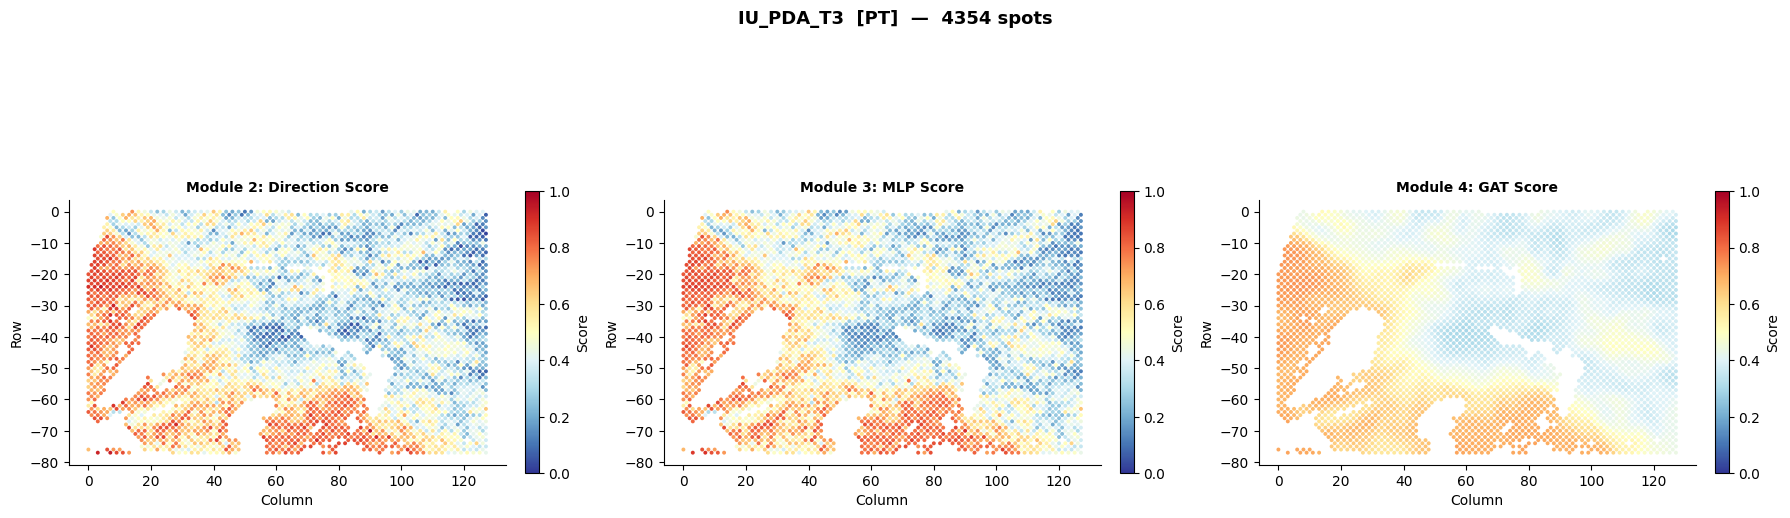

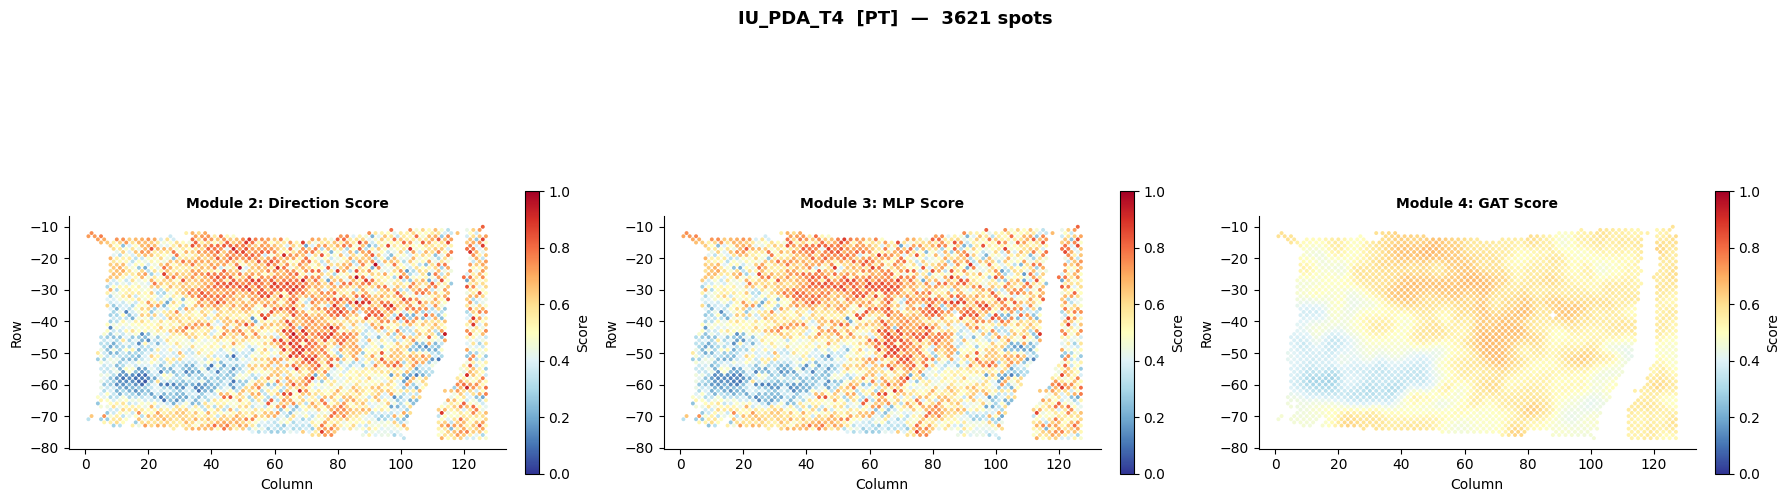

Done.


In [24]:
# ── Plot 2: Spatial heatmaps for ALL samples ──────────────────────────────────
score_cols = ['direction_score', 'mlp_score', 'final_score']
titles     = ['Module 2: Direction Score', 'Module 3: MLP Score', 'Module 4: GAT Score']

all_samples = results['sample_id'].unique()
print(f'Plotting {len(all_samples)} samples...')

for sample_id in sorted(all_samples):
    sdf = results[results['sample_id'] == sample_id].copy()
    cohort = sdf['cohort'].iloc[0]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for ax, col, title in zip(axes, score_cols, titles):
        sc = ax.scatter(
            sdf['col'], -sdf['row'],
            c=sdf[col], cmap='RdYlBu_r',
            vmin=0, vmax=1, s=8, linewidths=0
        )
        plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.04, label='Score')
        ax.set_title(f'{title}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Column'); ax.set_ylabel('Row')
        ax.set_aspect('equal')
        ax.spines[['top', 'right']].set_visible(False)

    plt.suptitle(f'{sample_id}  [{cohort}]  —  {len(sdf)} spots',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/spatial_heatmap_{sample_id}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

print('Done.')

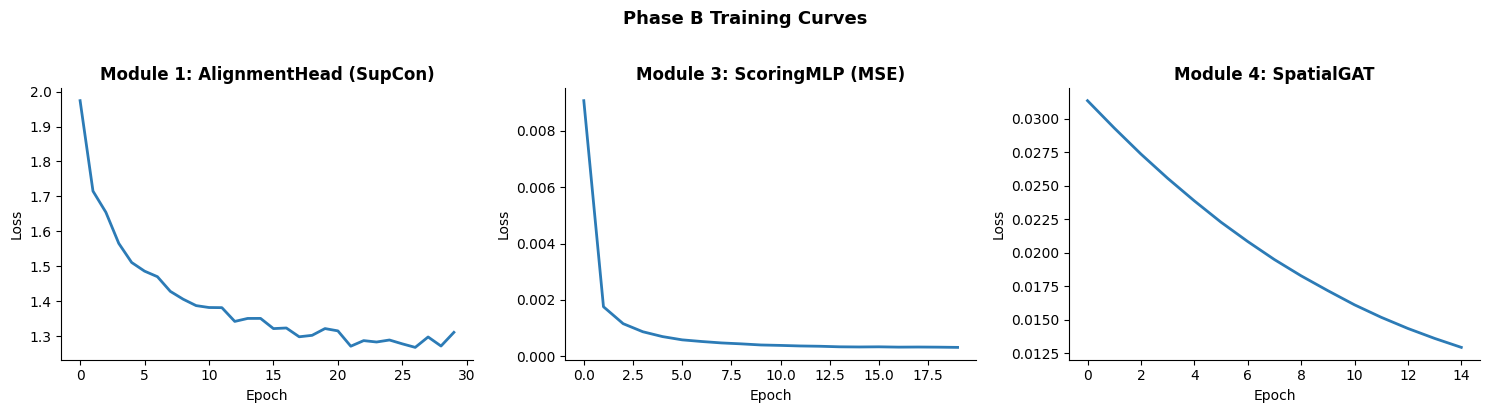

In [25]:
# ── Plot 3: Training loss curves ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, losses, title in zip(
    axes,
    [align_losses, score_losses, gat_losses],
    ['Module 1: AlignmentHead (SupCon)', 'Module 3: ScoringMLP (MSE)', 'Module 4: SpatialGAT']
):
    ax.plot(losses, linewidth=2, color='#2c7bb6')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Phase B Training Curves', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# ── Per-patient summary (clinical output) ─────────────────────────────────────
# Extract patient ID from sample_id (adjust split logic to your naming convention)
# e.g. 'PT_P01_S1' -> patient 'P01'
results['patient_id'] = results['sample_id'].str.extract(r'(P\d+)')

patient_summary = (
    results
    .groupby(['patient_id', 'cohort'])
    .agg(
        n_spots          = ('final_score', 'count'),
        mean_meta_score  = ('final_score', 'mean'),
        high_risk_spots  = ('final_score', lambda x: (x > 0.7).sum()),
        pct_high_risk    = ('final_score', lambda x: 100 * (x > 0.7).mean())
    )
    .reset_index()
    .sort_values('mean_meta_score', ascending=False)
)

patient_summary.to_csv('/kaggle/working/phase_b_patient_summary.csv', index=False)
print('Patient-level metastatic risk summary:')
print(patient_summary.to_string(index=False))

Patient-level metastatic risk summary:
Empty DataFrame
Columns: [patient_id, cohort, n_spots, mean_meta_score, high_risk_spots, pct_high_risk]
Index: []


In [27]:
# ── Save full Phase B config for reproducibility ──────────────────────────────
config = {
    'phase_a_backbone':   'UNI2-h (1536d)',
    'phase_a_gene':       'scVI (50d)',
    'phase_a_cell':       'RCTD (15d)',
    'phase_a_output_dim': 256,
    'module1_out_dim':    128,
    'module1_epochs':     ALIGN_EPOCHS,
    'module1_lr':         ALIGN_LR,
    'gene_sim_threshold': GENE_SIM_THRESH,
    'module3_epochs':     SCORE_EPOCHS,
    'module4_epochs':     GAT_EPOCHS,
    'gat_heads':          4,
    'spatial_k_neighbors':6,
    'high_risk_threshold':0.7,
    'seed':               SEED
}

with open('/kaggle/working/phase_b_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('Phase B complete. Outputs saved to /kaggle/working/')
print('  phase_b_align_head.pt')
print('  phase_b_scoring_mlp.pt')
print('  phase_b_spatial_gat.pt')
print('  phase_b_spot_scores.csv')
print('  phase_b_patient_summary.csv')
print('  phase_b_config.json')
print('  score_distributions.png')
print('  spatial_heatmap.png')
print('  training_curves.png')

Phase B complete. Outputs saved to /kaggle/working/
  phase_b_align_head.pt
  phase_b_scoring_mlp.pt
  phase_b_spatial_gat.pt
  phase_b_spot_scores.csv
  phase_b_patient_summary.csv
  phase_b_config.json
  score_distributions.png
  spatial_heatmap.png
  training_curves.png


In [44]:
import shutil

shutil.make_archive('/kaggle/working/phase_b_outputs', 'zip', '/kaggle/working')

print('Done. Download: /kaggle/working/phase_b_outputs.zip')

RuntimeError: File size too large, try using force_zip64